### Predicting heart disease using ML
This notebook looks into using various Python-based machine learning and data science libraries 
in attempt to build a ML model capable of predicting whether or not someone has heart disease
on their medical attributes.

We're going to take the following approach:
1. Problem Definition
2. Data
3. Evaluation
4. Features
5. Modelling
6. Experimentation

## 1. Problem Definition

In a statement,
> Given clinical parameters about a patient, can we predict whether or not they have heart disease ?

## 2.Data

The original data came from the Cleavland data from the UCI Machine Learning Repository. https://archive.ics.uci.edu/ml/datasets/heart+Disease

There is also a version of it available on Kaggle. https://www.kaggle.com/ronitf/heart-disease-uci

## 3. Evaluation

> If we can reach 95% accuracy at predicting whether or not a patient has heart disease during the proof of concept, we'll pursue the project.

## 4. Features

This is where we'll get different information about each of the features in your data.

**Create data dictionary**

* ageage in years
* sex(1 = male; 0 female)
* cp chest pain type
* trestbpsresting blood pressure (in mm Hg on admission to the hospital)
* chol serum cholestoral in mg/dl
* fbs (fasting blood sugar > 120 mg/dl) (1 = true; 0 = false)
* restecgresting electrocardiographic results
* thalachmaximum heart rate achieved
* exangexercise induced angina ( 1 = yes 0 = no )
* oldpeakST depression induced by exercise relative to rest
* slopethe slope of the peak exercise ST segment
* canumber of major vessels (0-3) colored by flourosopy
* thal3 normal; 6 fixed defect; 7 = reversable defect
* target 1 or 0

* age - age in years
* sex - (1 = male; 0 = female)
* cp - chest pain type
  0: Typical angina: chest pain related decrease blood supply to the heart
  1: Atypical angina: chest pain not related to heart
  2: Non-anginal pain: typically esophageal spasms (non heart related)
  3: Asymptomatic: chest pain not showing signs of disease
* trestbps - resting blood pressure (in mm Hg on admission to the hospital) anything above 130-140 is typically cause for concern

This means, in this case, strangely enough, according to the correlation value here, if someone gets chest pain during depression induced by uxercise relative to rest look. stress of heart during excercise unhealthy h exercise (exang = 1), their chance of having heart
goes down (target = 0). segmen 0: Upsloping: bette heart rate with excercise (uncommon)

* chol - serum cholestoral in mg/dl
  
* serum = LDL + HDL + .2 * triglycerides
  above 200 is cause for concern

  
* fbs - (fasting blood sugar > 120 mg/dl) (1 = true; 0 = false)
  '>126' mg/dL signals diabetes

  
* restecg - resting electrocardiographic results
  0: Nothing to note
  1: ST-T Wave abnormality

  
* can range from mild symptoms to severe problems
 signals non-normal heart beat


* 2: Possible or definite left ventricular hypertrophy

  
* Enlarged heart's main pumping chamber

  
* thalach - maximum heart rate achieved

  
* exang - exercise induced angina (1 = yes; 0 = no)

  
oldpeak - ST depression induced by exercise relative to rest looks at stress of heart during excercise unhealthy heart will stress more

slope - the slope of the peak exercise ST segment

0: Upsloping: better heart rate with excercise (uncommon)

1: Flatsloping: minimal change (typical healthy heart)

2: Downslopins: signs of unhealthy heart

ca - number of major vessels (0-3) colored by flourosopy

colored vessel means the doctor can see the blood passing through
the more blood movement the better (no clots)
thal - thalium stress result

1,3: normal

6: fixed defect: used to be defect but ok now

7: reversable defect: no proper blood movement when excercising
target - have disease or not (1=yes, 0=no) (= the predicted attribute)


Previous code (before Scikit-Learn version 1.2)

## this will error in Scikit-Learn version 1.2+
from sklearn.metrics import plot_roc_curve 
New code (after Scikit-Learn version 1.2)

## Available in Scikit-Learn version 1.2+
from sklearn.metrics import RocCurveDisplay 

## Preparing Tools
We're going to use pandas, Matplotlib and NumPy for data analysis and manipulation.

In [10]:
# Import all the tools we need

#Regular EDA (exploratory data analysis) and plotting libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

#we want our plots to appera inside the notebook
%matplotlib inline

# Models from Scikit-learn
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

#Model Evaluation
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import RocCurveDisplay

### Load data

In [12]:
df = pd.read_csv("heart disease classification dataset.csv")
df

,Unnamed: 0,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,0,63,male,3,145.0,233.0,1,0,150.0,0,2.3,0,0,1,yes
1,1,37,male,2,130.0,250.0,0,1,187.0,0,3.5,0,0,2,yes
2,2,41,female,1,130.0,204.0,0,0,172.0,0,1.4,2,0,2,yes
3,3,56,male,1,120.0,236.0,0,1,178.0,0,0.8,2,0,2,yes
4,4,57,female,0,NaN,354.0,0,1,163.0,1,0.6,2,0,2,yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,298,57,female,0,140.0,241.0,0,1,123.0,1,0.2,1,0,3,no
299,299,45,male,3,110.0,264.0,0,1,132.0,0,1.2,1,0,3,no
300,300,68,male,0,144.0,193.0,1,1,141.0,0,3.4,1,2,3,no
301,301,57,male,0,NaN,131.0,0,1,115.0,1,1.2,1,1,3,no


In [13]:
df.shape

(303, 15)

## Data Exploration( exploratory data analysis or EDA)

The goal here is to find out more about the data and become a subject matter expert on the dataset we're working with. 
  1. What question(s) are you trying to solve?
  2. What kind of data do we have and how do we treat different types?
  3. What's missing from the data and how do you deal with it?
  4. Where are the outliers and why should you care about them?
  5. How can you add, change or remove features to get more out of your data?

In [14]:
df.head() 

,Unnamed: 0,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,0,63,male,3,145.0,233.0,1,0,150.0,0,2.3,0,0,1,yes
1,1,37,male,2,130.0,250.0,0,1,187.0,0,3.5,0,0,2,yes
2,2,41,female,1,130.0,204.0,0,0,172.0,0,1.4,2,0,2,yes
3,3,56,male,1,120.0,236.0,0,1,178.0,0,0.8,2,0,2,yes
4,4,57,female,0,NaN,354.0,0,1,163.0,1,0.6,2,0,2,yes


In [15]:
df.tail() 

,Unnamed: 0,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
298,298,57,female,0,140.0,241.0,0,1,123.0,1,0.2,1,0,3,no
299,299,45,male,3,110.0,264.0,0,1,132.0,0,1.2,1,0,3,no
300,300,68,male,0,144.0,193.0,1,1,141.0,0,3.4,1,2,3,no
301,301,57,male,0,NaN,131.0,0,1,115.0,1,1.2,1,1,3,no
302,302,57,female,1,130.0,236.0,0,0,174.0,0,0.0,1,1,2,no


In [16]:
# Let's find out how many of each class there
df["target"].value_counts() 

target
yes    165
no     138
Name: count, dtype: int64

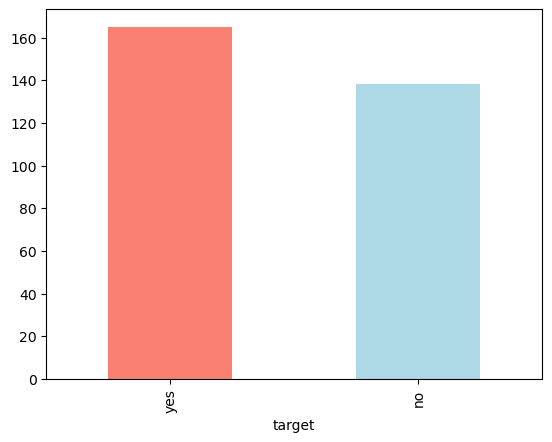

In [17]:
df["target"].value_counts().plot(kind="bar", color=["salmon", "lightblue"]);


In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  303 non-null    int64  
 1   age         303 non-null    int64  
 2   sex         303 non-null    str    
 3   cp          303 non-null    int64  
 4   trestbps    299 non-null    float64
 5   chol        302 non-null    float64
 6   fbs         303 non-null    int64  
 7   restecg     303 non-null    int64  
 8   thalach     298 non-null    float64
 9   exang       303 non-null    int64  
 10  oldpeak     303 non-null    float64
 11  slope       303 non-null    int64  
 12  ca          303 non-null    int64  
 13  thal        303 non-null    int64  
 14  target      303 non-null    str    
dtypes: float64(4), int64(9), str(2)
memory usage: 35.6 KB


In [19]:
#Are there any missing values?
df.isna().sum() 

Unnamed: 0    0
age           0
sex           0
cp            0
trestbps      4
chol          1
fbs           0
restecg       0
thalach       5
exang         0
oldpeak       0
slope         0
ca            0
thal          0
target        0
dtype: int64

In [20]:
df.describe() 

,Unnamed: 0,age,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
count,303.000000,303.000000,303.000000,299.000000,302.000000,303.000000,303.000000,298.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,151.000000,54.366337,0.966997,131.712375,246.317881,0.148515,0.528053,149.865772,0.326733,1.039604,1.399340,0.729373,2.313531
std,87.612784,9.082101,1.032052,17.629032,51.908285,0.356198,0.525860,22.563687,0.469794,1.161075,0.616226,1.022606,0.612277
min,0.000000,29.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,75.500000,47.500000,0.000000,120.000000,211.000000,0.000000,0.000000,134.500000,0.000000,0.000000,1.000000,0.000000,2.000000
50%,151.000000,55.000000,1.000000,130.000000,240.500000,0.000000,1.000000,152.500000,0.000000,0.800000,1.000000,0.000000,2.000000
75%,226.500000,61.000000,2.000000,140.000000,274.750000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000
max,302.000000,77.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000


In [21]:
df.head()

,Unnamed: 0,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,0,63,male,3,145.0,233.0,1,0,150.0,0,2.3,0,0,1,yes
1,1,37,male,2,130.0,250.0,0,1,187.0,0,3.5,0,0,2,yes
2,2,41,female,1,130.0,204.0,0,0,172.0,0,1.4,2,0,2,yes
3,3,56,male,1,120.0,236.0,0,1,178.0,0,0.8,2,0,2,yes
4,4,57,female,0,NaN,354.0,0,1,163.0,1,0.6,2,0,2,yes


In [22]:
df.tail() 

,Unnamed: 0,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
298,298,57,female,0,140.0,241.0,0,1,123.0,1,0.2,1,0,3,no
299,299,45,male,3,110.0,264.0,0,1,132.0,0,1.2,1,0,3,no
300,300,68,male,0,144.0,193.0,1,1,141.0,0,3.4,1,2,3,no
301,301,57,male,0,NaN,131.0,0,1,115.0,1,1.2,1,1,3,no
302,302,57,female,1,130.0,236.0,0,0,174.0,0,0.0,1,1,2,no


In [23]:
#Let's find out how many of each class there
df["target"].value_counts() 

target
yes    165
no     138
Name: count, dtype: int64

## Heart Disease Frequency according to Sex

In [24]:
df.sex.value_counts() 

sex
male      207
female     96
Name: count, dtype: int64

In [25]:
#Compare target column with sex column
pd.crosstab(df.target, df.sex) 

sex,female,male
target,,
no,24,114
yes,72,93


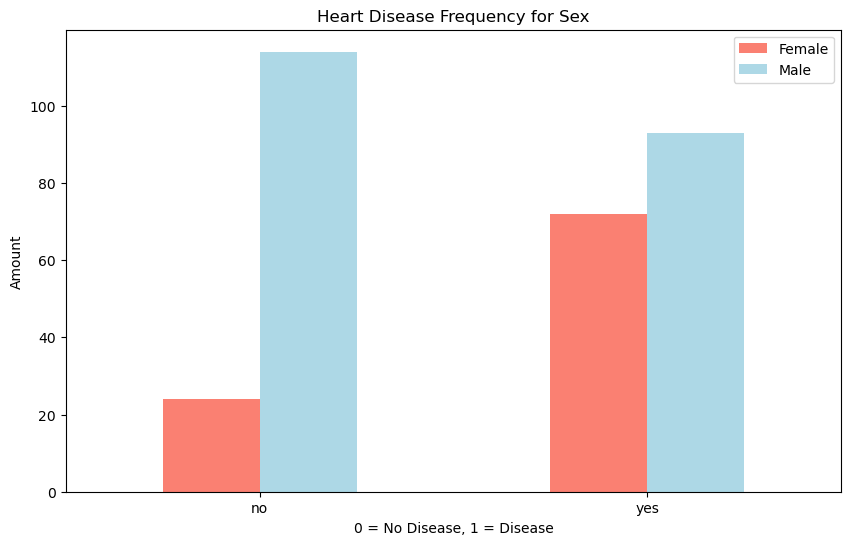

In [29]:
#Create a plot of crosstab
pd.crosstab(df.target, df.sex).plot(kind="bar",
                                    figsize=(10, 6),
                                    color=["salmon", "lightblue"])
plt.title("Heart Disease Frequency for Sex")
plt.xlabel("0 = No Disease, 1 = Disease")
plt.ylabel("Amount")
plt.legend(["Female", "Male"]);
plt.xticks(rotation=0);


In [31]:
df["thalach"].value_counts() 

thalach
162.0    11
160.0     9
163.0     8
173.0     8
152.0     8
         ..
95.0      1
117.0     1
71.0      1
118.0     1
134.0     1
Name: count, Length: 89, dtype: int64

### Age vs. Max Heart Rate for Heart Disease

In [73]:
print(df_original.age.min(), df_original.age.max())
print(df_original.thalach.min(), df_original.thalach.max())

29 77
71.0 202.0


In [74]:
#converting from boolean to integer
df_original["target"] = df_original["target"].map({"no": 0, "yes": 1}) 

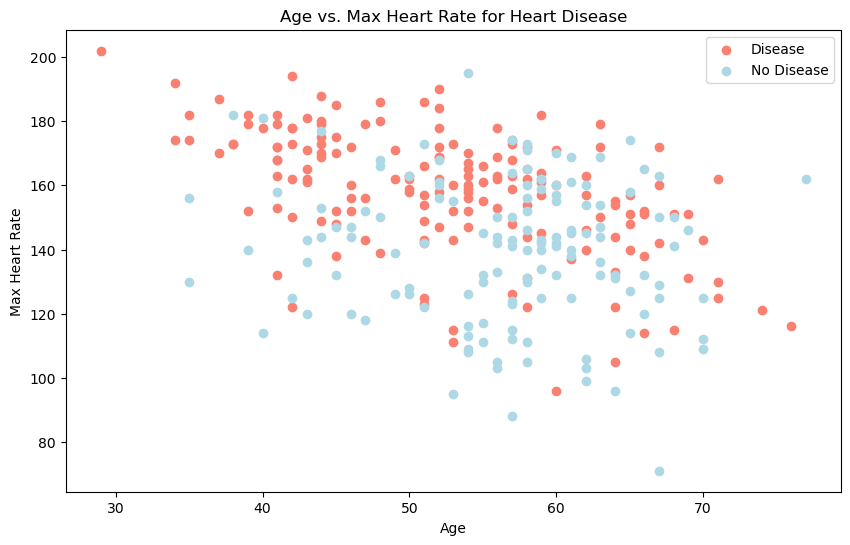

In [75]:
#Create another figure
plt.figure(figsize=(10, 6))

#Scatter with positive examples
plt.scatter(df_original.age[df_original.target==1],
            df_original.thalach[df_original.target == 1],
            c="salmon",
            label="Disease") 
#Scatter with negative examples
plt.scatter(df_original.age[df_original.target==0],
            df_original.thalach[df_original.target==0],
            c="lightblue",
            label="No Disease") 

plt.xlabel("Age")
plt.ylabel("Max Heart Rate")
plt.title("Age vs. Max Heart Rate for Heart Disease")
plt.legend()

plt.show() 



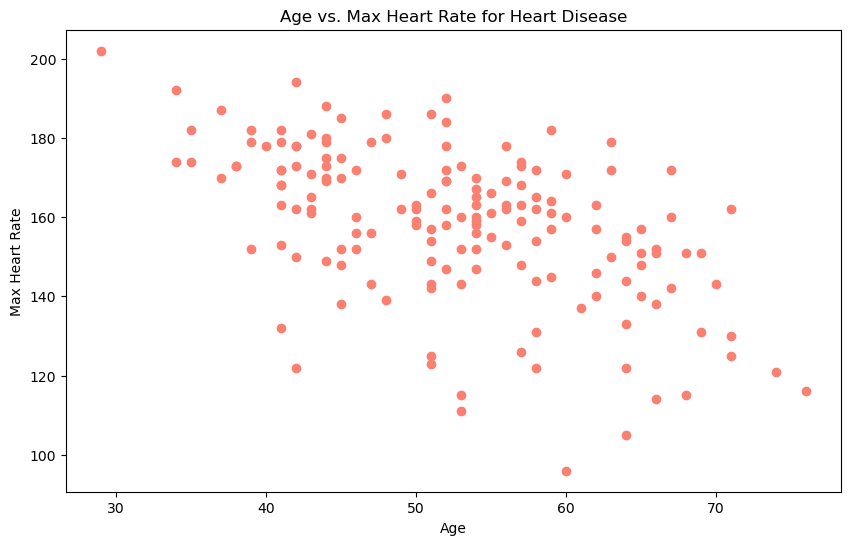

In [61]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df_original.age[df_original.target == 1],
    df_original.thalach[df_original.target == 1],
    c="salmon"
)

plt.xlabel("Age")
plt.ylabel("Max Heart Rate")
plt.title("Age vs. Max Heart Rate for Heart Disease")
plt.show() 

In [62]:
print(len(df[df.target == 1]))
print(len(df[df.target == 0])) 

0
0


In [63]:
print(df.shape)
print(df.target.value_counts())

(303, 15)
target
yes    165
no     138
Name: count, dtype: int64


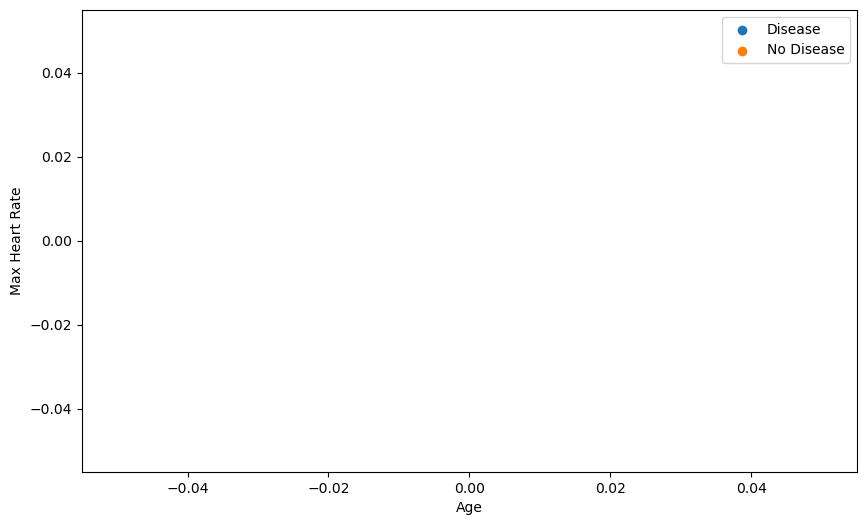

In [64]:
df_original = pd.read_csv("heart disease classification dataset.csv") 

plt.figure(figsize=(10, 6))

plt.scatter(df_original.age[df_original.target == 1],
            df_original.thalach[df_original.target == 1],
            label="Disease")

plt.scatter(df_original.age[df_original.target == 0],
            df_original.thalach[df_original.target == 0],
            label="No Disease")

plt.xlabel("Age")
plt.ylabel("Max Heart Rate")
plt.legend()
plt.show()

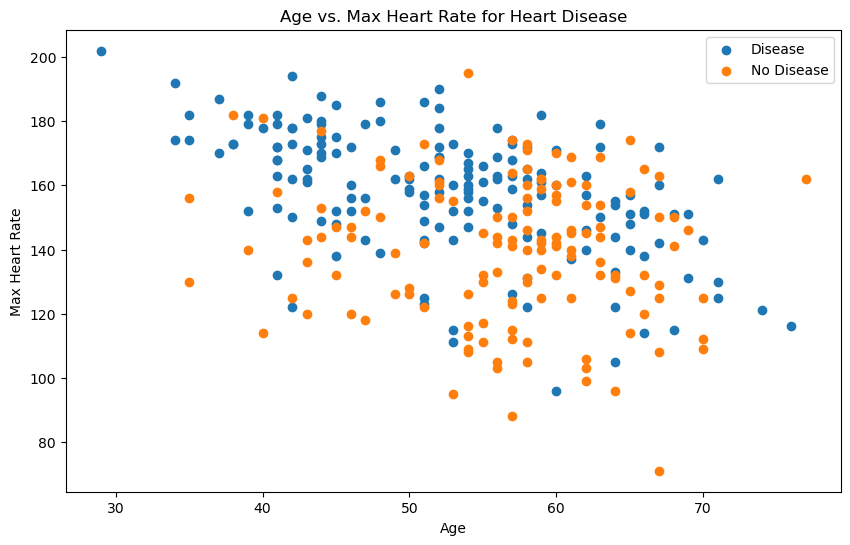

In [65]:
df_original = pd.read_csv("heart disease classification dataset.csv")

plt.figure(figsize=(10, 6))

plt.scatter(
    df_original.age[df_original.target == "yes"],
    df_original.thalach[df_original.target == "yes"],
    label="Disease"
)

plt.scatter(
    df_original.age[df_original.target == "no"],
    df_original.thalach[df_original.target == "no"],
    label="No Disease"
)

plt.xlabel("Age")
plt.ylabel("Max Heart Rate")
plt.title("Age vs. Max Heart Rate for Heart Disease")
plt.legend()
plt.show() 

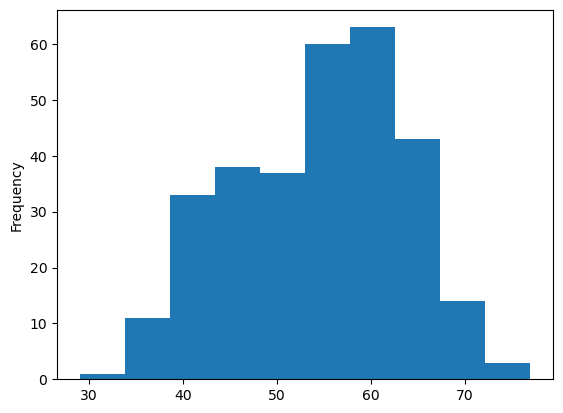

In [76]:
#Check the distribution of age column with a histogram
df.age.plot.hist(); 

### Heart Disease Frequency per Chest Pain Type
3. cp - chest pain type
   
   0: Typical angina: chest pain related decrease blood supply to the heart
   
   1: Atypical angina: chest pain not related to heart
   
   2: Non-anginal pain: typically esophageal spasma (non heart related)
   
   3: Asymptomatic: chest pain not showing signs of disease 
 

In [84]:
import pandas as pd
df1 = pd.read_csv("heart disease classification dataset.csv")
df1
#converting from boolean to integer
df1["target"] = df1["target"].map({"no": 0, "yes": 1}) 

In [86]:
pd.crosstab(df1.cp, df1.target) 

target,0,1
cp,,
0,104,39
1,9,41
2,18,69
3,7,16


(array([0, 1, 2, 3]),
 [Text(0, 0, '0'), Text(1, 0, '1'), Text(2, 0, '2'), Text(3, 0, '3')])

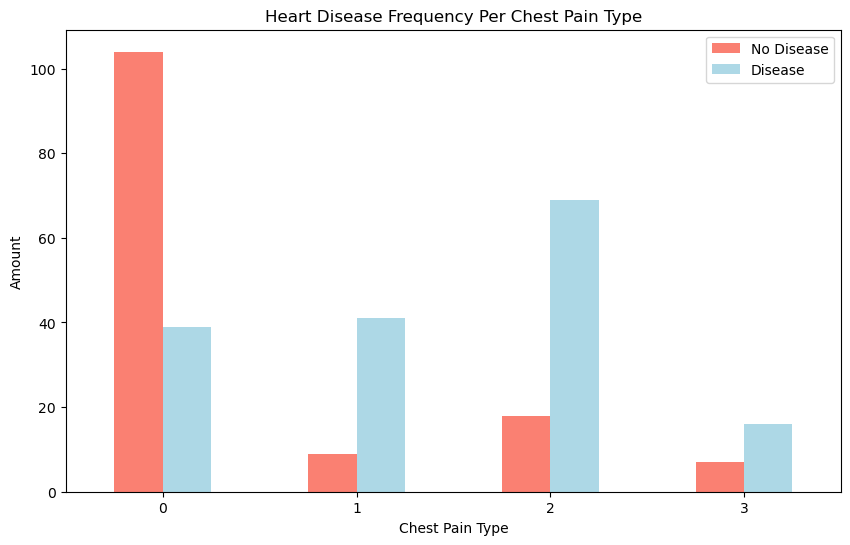

In [87]:
# Make the crosstab more visual
pd.crosstab(df.cp, df.target).plot(kind="bar",
                                   figsize=(10, 6),
                                   color=["salmon", "lightblue"])
#Add some communication
plt.title("Heart Disease Frequency Per Chest Pain Type")
plt.xlabel("Chest Pain Type")
plt.ylabel("Amount")
plt.legend(["No Disease", "Disease"])
plt.xticks(rotation=0)

In [109]:
import pandas as pd

df = pd.read_csv("heart disease classification dataset.csv")

# check actual values first
print(df["sex"].unique())
print(df["target"].unique())

<StringArray>
['male', 'female']
Length: 2, dtype: str
<StringArray>
['yes', 'no']
Length: 2, dtype: str


In [110]:
df["sex"] = df["sex"].map({"female": 0, "male": 1})
df["target"] = df["target"].map({"no": 0, "yes": 1})

In [111]:
df.head() 

,Unnamed: 0,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,0,63,1,3,145.0,233.0,1,0,150.0,0,2.3,0,0,1,1
1,1,37,1,2,130.0,250.0,0,1,187.0,0,3.5,0,0,2,1
2,2,41,0,1,130.0,204.0,0,0,172.0,0,1.4,2,0,2,1
3,3,56,1,1,120.0,236.0,0,1,178.0,0,0.8,2,0,2,1
4,4,57,0,0,NaN,354.0,0,1,163.0,1,0.6,2,0,2,1


In [100]:
# convert sex column
df["sex"] = df["sex"].map({"female": 0, "male": 1})

# optional: drop unwanted index-like column
df = df.drop("Unnamed: 0", axis=1)

# correlation matrix
df.corr(numeric_only=True) 

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
age,1.000000,-0.098447,-0.068653,0.279570,0.213465,0.121308,-0.116211,-0.396302,0.096801,0.210013,-0.168814,0.276326,0.068001,NaN
sex,-0.098447,1.000000,-0.049353,-0.064347,-0.197387,0.045032,-0.058196,-0.051491,0.141664,0.096093,-0.030711,0.118261,0.210041,NaN
cp,-0.068653,-0.049353,1.000000,0.048142,-0.078008,0.094444,0.044421,0.301567,-0.394280,-0.149230,0.119717,-0.181053,-0.161736,NaN
trestbps,0.279570,-0.064347,0.048142,1.000000,0.127278,0.175885,-0.110966,-0.029729,0.070183,0.193827,-0.121380,0.098499,0.060437,NaN
chol,0.213465,-0.197387,-0.078008,0.127278,1.000000,0.012865,-0.150330,-0.022939,0.066362,0.053098,-0.003027,0.070807,0.098328,NaN
fbs,0.121308,0.045032,0.094444,0.175885,0.012865,1.000000,-0.084189,0.001599,0.025665,0.005747,-0.059894,0.137979,-0.032019,NaN
restecg,-0.116211,-0.058196,0.044421,-0.110966,-0.150330,-0.084189,1.000000,0.037393,-0.070733,-0.058770,0.093045,-0.072042,-0.011981,NaN
thalach,-0.396302,-0.051491,0.301567,-0.029729,-0.022939,0.001599,0.037393,1.000000,-0.396211,-0.346806,0.380764,-0.208967,-0.106621,NaN
exang,0.096801,0.141664,-0.394280,0.070183,0.066362,0.025665,-0.070733,-0.396211,1.000000,0.288223,-0.257748,0.115739,0.206754,NaN
oldpeak,0.210013,0.096093,-0.149230,0.193827,0.053098,0.005747,-0.058770,-0.346806,0.288223,1.000000,-0.577537,0.222682,0.210244,NaN


#press shift leftarrow for suggestion

In [112]:
#Make a correlation matrix
df.corr() 

,Unnamed: 0,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
Unnamed: 0,1.000000,0.185153,0.201132,-0.399163,0.103337,0.021627,0.000743,-0.021130,-0.393974,0.363788,0.298161,-0.276484,0.384962,0.257403,-0.862585
age,0.185153,1.000000,-0.098447,-0.068653,0.279570,0.213465,0.121308,-0.116211,-0.396302,0.096801,0.210013,-0.168814,0.276326,0.068001,-0.225439
sex,0.201132,-0.098447,1.000000,-0.049353,-0.064347,-0.197387,0.045032,-0.058196,-0.051491,0.141664,0.096093,-0.030711,0.118261,0.210041,-0.280937
cp,-0.399163,-0.068653,-0.049353,1.000000,0.048142,-0.078008,0.094444,0.044421,0.301567,-0.394280,-0.149230,0.119717,-0.181053,-0.161736,0.433798
trestbps,0.103337,0.279570,-0.064347,0.048142,1.000000,0.127278,0.175885,-0.110966,-0.029729,0.070183,0.193827,-0.121380,0.098499,0.060437,-0.142035
chol,0.021627,0.213465,-0.197387,-0.078008,0.127278,1.000000,0.012865,-0.150330,-0.022939,0.066362,0.053098,-0.003027,0.070807,0.098328,-0.086563
fbs,0.000743,0.121308,0.045032,0.094444,0.175885,0.012865,1.000000,-0.084189,0.001599,0.025665,0.005747,-0.059894,0.137979,-0.032019,-0.028046
restecg,-0.021130,-0.116211,-0.058196,0.044421,-0.110966,-0.150330,-0.084189,1.000000,0.037393,-0.070733,-0.058770,0.093045,-0.072042,-0.011981,0.137230
thalach,-0.393974,-0.396302,-0.051491,0.301567,-0.029729,-0.022939,0.001599,0.037393,1.000000,-0.396211,-0.346806,0.380764,-0.208967,-0.106621,0.413252
exang,0.363788,0.096801,0.141664,-0.394280,0.070183,0.066362,0.025665,-0.070733,-0.396211,1.000000,0.288223,-0.257748,0.115739,0.206754,-0.436757


(15.5, -0.5)

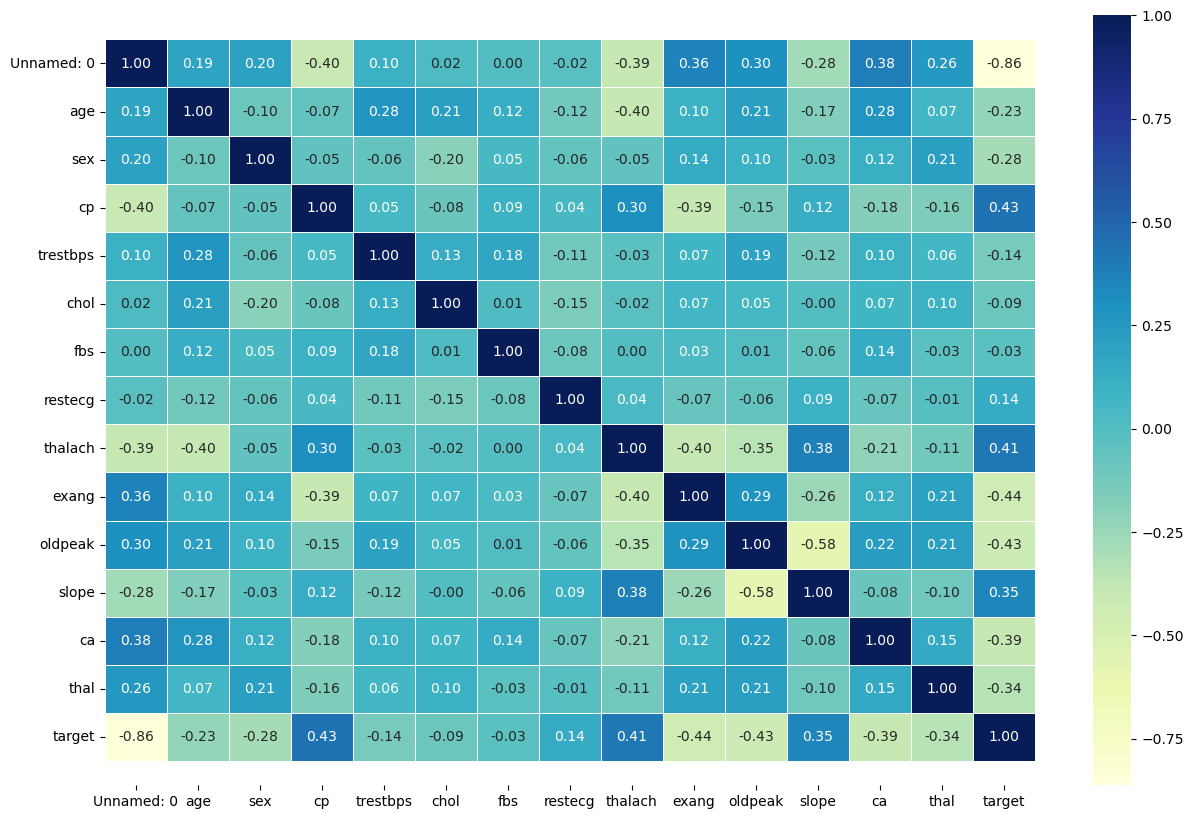

In [115]:
#Making correlation prettier
corr_matrix = df.corr()
fig, ax = plt.subplots(figsize=(15, 10))
ax = sns.heatmap(corr_matrix,
                 annot=True,
                 linewidths=0.5,
                 fmt=".2f",
                 cmap="YlGnBu");
bottom, top = ax.get_ylim()
ax.set_ylim(bottom + 0.5, top - 0.5) 

### 5. Modelling

In [116]:
df.head() 

,Unnamed: 0,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,0,63,1,3,145.0,233.0,1,0,150.0,0,2.3,0,0,1,1
1,1,37,1,2,130.0,250.0,0,1,187.0,0,3.5,0,0,2,1
2,2,41,0,1,130.0,204.0,0,0,172.0,0,1.4,2,0,2,1
3,3,56,1,1,120.0,236.0,0,1,178.0,0,0.8,2,0,2,1
4,4,57,0,0,NaN,354.0,0,1,163.0,1,0.6,2,0,2,1


In [117]:
# Split data into X, Y
X = df.drop("target", axis=1)

y = df["target"]

In [118]:
X

,Unnamed: 0,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,0,63,1,3,145.0,233.0,1,0,150.0,0,2.3,0,0,1
1,1,37,1,2,130.0,250.0,0,1,187.0,0,3.5,0,0,2
2,2,41,0,1,130.0,204.0,0,0,172.0,0,1.4,2,0,2
3,3,56,1,1,120.0,236.0,0,1,178.0,0,0.8,2,0,2
4,4,57,0,0,NaN,354.0,0,1,163.0,1,0.6,2,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,298,57,0,0,140.0,241.0,0,1,123.0,1,0.2,1,0,3
299,299,45,1,3,110.0,264.0,0,1,132.0,0,1.2,1,0,3
300,300,68,1,0,144.0,193.0,1,1,141.0,0,3.4,1,2,3
301,301,57,1,0,NaN,131.0,0,1,115.0,1,1.2,1,1,3


In [119]:
y

0      1
1      1
2      1
3      1
4      1
      ..
298    0
299    0
300    0
301    0
302    0
Name: target, Length: 303, dtype: int64

In [120]:
#Split data into train and test sets
np.random.seed(42)

#Split into train & test set
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2)

In [121]:
X_train

,Unnamed: 0,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
132,132,42,1,1,120.0,295.0,0,1,162.0,0,0.0,2,0,2
202,202,58,1,0,150.0,270.0,0,0,111.0,1,0.8,2,0,3
196,196,46,1,2,150.0,231.0,0,1,147.0,0,3.6,1,0,2
75,75,55,0,1,135.0,250.0,0,0,161.0,0,1.4,1,0,2
176,176,60,1,0,117.0,230.0,1,1,160.0,1,1.4,2,2,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
188,188,50,1,2,140.0,233.0,0,1,163.0,0,0.6,1,1,3
71,71,51,1,2,94.0,227.0,0,1,154.0,1,0.0,2,1,3
106,106,69,1,3,160.0,234.0,1,0,131.0,0,0.1,1,1,2
270,270,46,1,0,120.0,249.0,0,0,144.0,0,0.8,2,0,3


In [122]:
y_train, len(y_train)

(132    1
 202    0
 196    0
 75     1
 176    0
       ..
 188    0
 71     1
 106    1
 270    0
 102    1
 Name: target, Length: 242, dtype: int64,
 242)

Now we've got our data split into training and test sets, it's time to build a machine learning model.

We'll train it (find the patterns) on the training set.

And we'll test it (use the patterns) on the test set.

We're going to try 3 different ML models:
1. Logistic Regression
2. K-Nearest Neighbours Classifier
3. Random Forest Classifier


In [129]:
# Put models in a dictionary
models = {"Logistic Regression": LogisticRegression(),
          "KNN": KNeighborsClassifier(),
          "RandomForest": RandomForestClassifier()}
#Create a function to fit and score models
def fit_and_score(models, X_train, X_test, y_train, y_test):
    """
    Fits and evaluates given machine learning models.
    models : a dict of different Scikit-Learn machine learning models
    X_train : training data(no labels)
    X_test : testing data(no labels)
    y_train : training labels
    y_test : test labels
    """
    # Set random seed
    np.random.seed(42)
    #Make a dictionary to keep model scores
    model_scores = {}
    #Loop through models
    for name, model in models.items():
        #Fit model to data
        model.fit(X_train, y_train)
        #Evaluate the model and append its score to model_scores
        model_scores[name] = model.score(X_test, y_test)
    return model_scores    

In [137]:
for col in ["trestbps", "chol", "thalach"]:
    train_mean = X_train[col].mean()
    X_train[col] = X_train[col].fillna(train_mean)
    X_test[col] = X_test[col].fillna(train_mean) 

In [138]:
model_scores = fit_and_score(models, X_train, X_test, y_train, y_test)
model_scores

/Users/pranjalisrivastava/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


{'Logistic Regression': 1.0, 'KNN': 1.0, 'RandomForest': 1.0}

In [131]:
fit_and_score?

Signature: fit_and_score(models, X_train, X_test, y_train, y_test)
Docstring:
Fits and evaluates given machine learning models.
models : a dict of different Scikit-Learn machine learning models
X_train : training data(no labels)
X_test : testing data(no labels)
y_train : training labels
y_test : test labels
File:      /var/folders/3f/vt32q8pd7wn1bvpjkd3gc4xw0000gn/T/ipykernel_84831/360640881.py
Type:      function

In [134]:
for col in ["trestbps", "chol", "thalach"]:
    train_mean = X_train[col].mean()
    X_train[col] = X_train[col].fillna(train_mean)
    X_test[col] = X_test[col].fillna(train_mean)

In [135]:
X_train.isna().sum() 

Unnamed: 0    0
age           0
sex           0
cp            0
trestbps      0
chol          0
fbs           0
restecg       0
thalach       0
exang         0
oldpeak       0
slope         0
ca            0
thal          0
dtype: int64

In [136]:
X_test.isna().sum() 

Unnamed: 0    0
age           0
sex           0
cp            0
trestbps      0
chol          0
fbs           0
restecg       0
thalach       0
exang         0
oldpeak       0
slope         0
ca            0
thal          0
dtype: int64

### Model Comparison

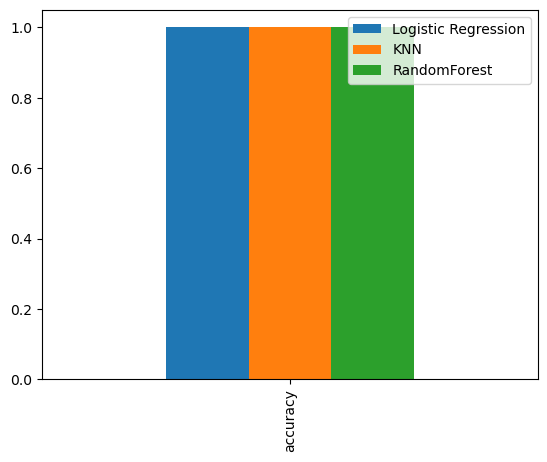

In [139]:
model_compare = pd.DataFrame(model_scores, index=["accuracy"])
model_compare.plot.bar();

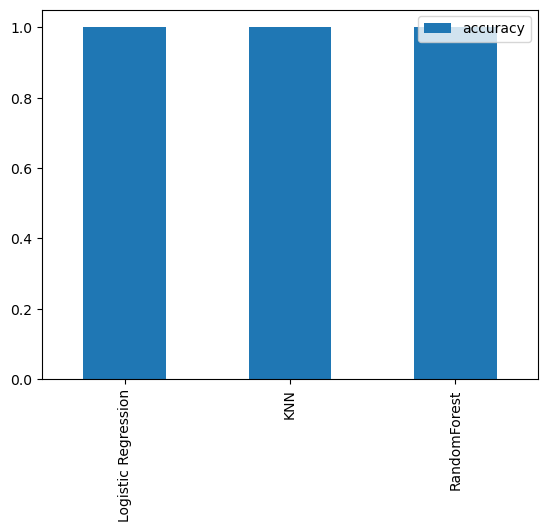

In [140]:
model_compare = pd.DataFrame(model_scores, index=["accuracy"])
model_compare.T.plot.bar();

## Now we've a baseline model.... and we know model's first predictions are aren't always what we should based our next steps off. What should do

Let's look at the following:
* Hypyterparameter tuning
* Feature importance
* Confusion matrix
* Cross-validation
* Precision
* Recall
* F1 score
* Classification report
* ROC curve
* Area under the curve (AUC)

## Hyperparameter tuning (by hand)

In [141]:
#Let's tune KNN

train_scores = []
test_scores = []

#Create a list of different values of n_neighbors
neighbors = range(1, 21)

#Setup KNN instance
knn = KNeighborsClassifier()

#Loop through different n_neighbors
for i in neighbors:
    knn.set_params(n_neighbors=i)

    #Fit the algorithm
    knn.fit(X_train, y_train)

    #Update the training scores list
    train_scores.append(knn.score(X_train, y_train))

    #Update the test scores list 
    test_scores.append(knn.score(X_test, y_test))
    

In [142]:
train_scores

[1.0,
 0.9793388429752066,
 0.9958677685950413,
 0.9917355371900827,
 0.9917355371900827,
 0.9958677685950413,
 0.9917355371900827,
 0.9917355371900827,
 0.9958677685950413,
 0.9917355371900827,
 0.9834710743801653,
 0.9834710743801653,
 0.9793388429752066,
 0.9834710743801653,
 0.9834710743801653,
 0.987603305785124,
 0.987603305785124,
 0.9917355371900827,
 0.987603305785124,
 0.987603305785124]

Maximum KNN score on the test data: 100.00%


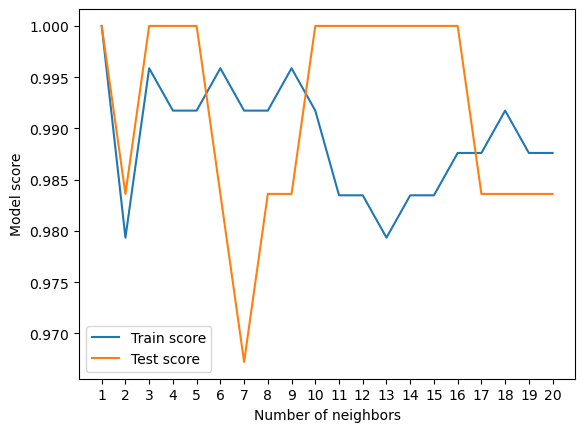

In [144]:
plt.plot(neighbors, train_scores, label="Train score")
plt.plot(neighbors, test_scores, label="Test score")
plt.xticks(np.arange(1, 21, 1))
plt.xlabel("Number of neighbors")
plt.ylabel("Model score")
plt.legend()

print(f"Maximum KNN score on the test data: {max(test_scores)*100:.2f}%")

## Hyperparameter tuning with RandomizedSearchCV

**We're going to tune:**

LogisticRegression()

RandomForestClassifier()

...using RandomizedSearchCV


In [161]:
#Create a hyperparameter grid for LogisticRegression
log_reg_grid = {"C": np.logspace(-4, 4, 20),
                "solver": ["liblinear"]}
#Create a hyperparameter grid for RandomForestClassifier
rf_grid = {"n_estimators": np.arange(10, 1000, 50),
           "max_depth": [None, 3, 5, 10],
           "min_samples_split": np.arange(2, 20, 2),
           "min_samples_leaf": np.arange(1, 20, 2)}


Now we've got hyperparameter grids setup for each of our models, let's tune them using   Randomized SearchCV...

In [162]:
#Tune LogisticRegression

np.random.seed(42)

#Setup random hyperparamter search for LogisticRegression
rs_log_reg = RandomizedSearchCV(LogisticRegression(),
                                param_distributions=log_reg_grid,
                                cv=5,
                                n_iter=20,
                                verbose=True)
#Fit random hyperparameter search model for LogisticRegression
rs_log_reg.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegression()
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'C': array([1.0000...00000000e+04]), 'solver': ['liblinear']}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fol

In [163]:
rs_log_reg.best_params_

{'solver': 'liblinear', 'C': np.float64(29.763514416313132)}

In [164]:
rs_log_reg.score(X_test, y_test) 

1.0

Now we've tuned LogisticRegression(), let's do the same for Random ForestClassifier()...

In [165]:
# Setup random seed
np.random.seed(42)

# Setup random hyperparameter search for RandomForestClassifier
rs_rf = RandomizedSearchCV(RandomForestClassifier(),
                           param_distributions=rf_grid,
                           cv=5,
                           n_iter=20,
                           verbose=True)

# Fit random hyperparameter search model for RandomForestClassifier()
rs_rf.fit(X_train, y_train) 

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestClassifier()
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [None, 3, ...], 'min_samples_leaf': array([ 1, 3..., 15, 17, 19]), 'min_samples_split': array([ 2, 4..., 14, 16, 18]), 'n_estimators': array([ 10, ...60, 910, 960])}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-valid

In [166]:
#Find the best hyperparameters
rs_rf.best_params_

{'n_estimators': np.int64(560),
 'min_samples_split': np.int64(16),
 'min_samples_leaf': np.int64(17),
 'max_depth': 5}

In [167]:
# Evaluate the randomized search RandomForestClassifier model
rs_rf.score (X_test, y_test) 

1.0

### Hyperparamter Tuning with GridSearchCV

Since our LogisticRegression model provides the best scores so far, we'll try and improve them again using GridSearchCV...

In [182]:
model_scores

{'Logistic Regression': 1.0, 'KNN': 1.0, 'RandomForest': 1.0}

In [183]:
# Different hyperparameters for our LogisticRegression model
log_reg_grid = {"C": np.logspace(-4, 4, 30),
                "solver": [ "liblinear"]}
# Setup grid hyperparameter search for LogisticRegression
gs_log_reg = GridSearchCV (LogisticRegression(),
                           param_grid=log_reg_grid,
                          cv=5,
                          verbose=True)
#Fit grid hyperparamter search model
gs_log_reg.fit(X_train, y_train);

Fitting 5 folds for each of 30 candidates, totalling 150 fits


In [184]:
#Check the best hyperparameters
gs_log_reg.best_params_

{'C': np.float64(0.1082636733874054), 'solver': 'liblinear'}

In [185]:
#Evaluate the grid search LogisticRegressionModel
gs_log_reg.score(X_test, y_test)

1.0

In [186]:
model_scores

{'Logistic Regression': 1.0, 'KNN': 1.0, 'RandomForest': 1.0}

Previous code (before Scikit-Learn version 1.2)

# this will error in Scikit-Learn version 1.2+
from sklearn.metrics import plot_roc_curve 
New code (after Scikit-Learn version 1.2)

# Available in Scikit-Learn version 1.2+
from sklearn.metrics import RocCurveDisplay 
How to check what Scikit-Learn version you're running

import sklearn
sklearn.__version__ # will print out the version number
How to update your Scikit-Learn version

Running this in your terminal with your Conda environment active will update Scikit-Learn to latest version (the -U stands for update).

pip install -U scikit-learn

More details

You can see more details about this on the course GitHub: https://github.com/mrdbourke/zero-to-mastery-ml/issues/45



## Evaluting our tuned machine learning classifier, beyond accuracy

* ROC curve and AUC score
* Confusion matrix
* Classification report
* Precision
* Recall
* Fl-score

... and it would be great if cross-validation was used where possible.

To make comparisons and evaluate our trained model, first we need to make predictions.

In [187]:
#Make predictions with tuned model
y_preds = gs_log_reg.predict(X_test)

In [188]:
y_preds

array([0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0,
       0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0])

In [189]:
y_test

179    0
228    0
111    1
246    0
60     1
      ..
249    0
104    1
300    0
193    0
184    0
Name: target, Length: 61, dtype: int64

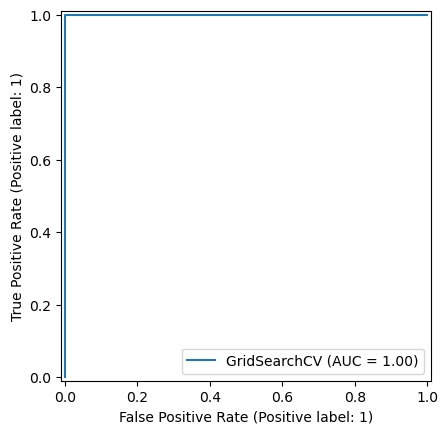

In [191]:
#Plot ROC curve and calculate AUC metric
RocCurveDisplay.from_estimator(gs_log_reg, X_test, y_test)

In [193]:
#Confusion Matrix
print(confusion_matrix(y_test, y_preds))

[[29  0]
 [ 0 32]]


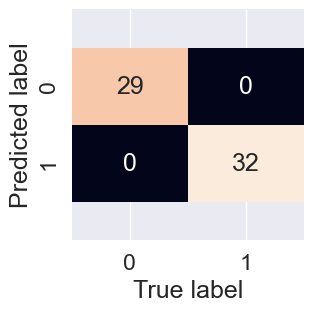

In [198]:
sns.set(font_scale=1.5)

def plot_conf_mat(y_test, y_preds):
    """
    Plots nice looking confusion matrix using Seaborn's heatmap()
    """
    fig, ax = plt.subplots(figsize=(3,3))
    ax = sns.heatmap(confusion_matrix(y_test, y_preds),
                     annot=True,
                     cbar=False)
    plt.xlabel("True label")
    plt.ylabel("Predicted label")
    
    bottom, top = ax.get_ylim() 
    ax.set_ylim(bottom + 0.5, top -0.5)
    

plot_conf_mat(y_test, y_preds)    

Now we've ROC curve, an AUC, confusion matrix, let's get classification report as well as cross-validated precision, recall and f1-score

In [199]:
print(classification_report(y_test, y_preds))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        29
           1       1.00      1.00      1.00        32

    accuracy                           1.00        61
   macro avg       1.00      1.00      1.00        61
weighted avg       1.00      1.00      1.00        61



### Calculate evaluation metrics using cross-validation

We're going to calculate accuray, precision, recall and f1-score of our model using cross_validation and to do so we'll using `cross_val_score()`.

In [202]:
#Check best hyperparameters
gs_log_reg.best_params_

{'C': np.float64(0.1082636733874054), 'solver': 'liblinear'}

In [205]:
X.isna().sum()

Unnamed: 0    0
age           0
sex           0
cp            0
trestbps      4
chol          1
fbs           0
restecg       0
thalach       5
exang         0
oldpeak       0
slope         0
ca            0
thal          0
dtype: int64

In [208]:
X_clean = X.drop("Unnamed: 0", axis=1, errors="ignore").copy()

for col in ["trestbps", "chol", "thalach"]:
    X_clean[col] = X_clean[col].fillna(X_clean[col].mean())

In [215]:
#Create a new classifier with best parameters
clf = LogisticRegression(C=0.20433597178569418,
                         solver="liblinear")


In [217]:
#Cross-validated accuracy
cv_acc = cross_val_score(clf,
                         X_clean,
                         y,
                         cv=5,
                         scoring="accuracy")
cv_acc

array([0.81967213, 0.8852459 , 0.86885246, 0.88333333, 0.75      ])

In [219]:
cv_acc = np.mean(cv_acc) 
cv_acc

np.float64(0.8414207650273223)

In [221]:
# Cross-validated precision
cv_precision = cross_val_score(clf,
                               X_clean,
                               y,
                               cv=5,
                               scoring="precision")
cv_precision = np.mean(cv_precision)
cv_precision

np.float64(0.8158730158730159)

In [223]:
# Cross-validated recall
cv_recall = cross_val_score(clf,
                               X_clean,
                               y,
                               cv=5,
                               scoring="recall")
cv_recall = np.mean(cv_recall)
cv_recall

np.float64(0.9212121212121213)

In [225]:
# Cross validated f1-score
cv_f1 = cross_val_score(clf,
                        X_clean,
                        y,
                        cv=5,
                        scoring="f1")
cv_f1 = np.mean(cv_f1)
cv_f1

np.float64(0.8646580013780378)

<Axes: title={'center': 'Cross-validated classification metrics'}>

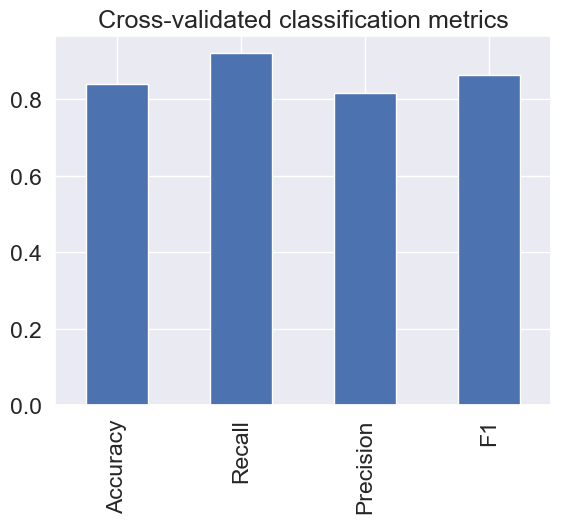

In [226]:
# Visualize cross-validated metrics
cv_metrics = pd. DataFrame({"Accuracy": cv_acc,
                            "Recall": cv_recall,
                            "Precision": cv_precision, 
                            "F1": cv_f1},
                            index=[0])
cv_metrics.T.plot.bar(title="Cross-validated classification metrics",
                      legend=False) 

### Feature importance
Feature importance is another as asking, "which features contributed most to the outcomes of the model and how did they contribute?"

Finding feature importance is different for each ML model. One way to find feature importance is to search for "(MODEL NAME) feature importance"

Let's find the feature importance for our LogisticRegressionModel..

In [231]:
# Fit an instance of LogisticRegression
clf = LogisticRegression (C = 0.20433597178569418, 
                        solver="liblinear")
clf.fit(X_train, y_train);

In [233]:
df.head()

,Unnamed: 0,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,0,63,1,3,145.0,233.0,1,0,150.0,0,2.3,0,0,1,1
1,1,37,1,2,130.0,250.0,0,1,187.0,0,3.5,0,0,2,1
2,2,41,0,1,130.0,204.0,0,0,172.0,0,1.4,2,0,2,1
3,3,56,1,1,120.0,236.0,0,1,178.0,0,0.8,2,0,2,1
4,4,57,0,0,NaN,354.0,0,1,163.0,1,0.6,2,0,2,1


In [234]:
# Check coef_
clf.coef_

array([[-0.31727282,  0.22008268, -0.0385787 ,  0.07348072,  0.16486364,
        -0.02609502, -0.02959642,  0.31274496,  0.16343653, -0.05220647,
        -0.68354915,  0.20766756, -0.13416198, -0.05659416]])

In [235]:
df.head()

,Unnamed: 0,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,0,63,1,3,145.0,233.0,1,0,150.0,0,2.3,0,0,1,1
1,1,37,1,2,130.0,250.0,0,1,187.0,0,3.5,0,0,2,1
2,2,41,0,1,130.0,204.0,0,0,172.0,0,1.4,2,0,2,1
3,3,56,1,1,120.0,236.0,0,1,178.0,0,0.8,2,0,2,1
4,4,57,0,0,NaN,354.0,0,1,163.0,1,0.6,2,0,2,1


In [236]:
#Match coef's of features to columns
feature_dict = dict(zip(df.columns, list(clf.coef_[0])))
feature_dict

{'Unnamed: 0': np.float64(-0.31727281837834564),
 'age': np.float64(0.22008267668934825),
 'sex': np.float64(-0.03857870064217414),
 'cp': np.float64(0.0734807193503308),
 'trestbps': np.float64(0.16486364411886914),
 'chol': np.float64(-0.026095015835357577),
 'fbs': np.float64(-0.02959641574780893),
 'restecg': np.float64(0.31274496259060836),
 'thalach': np.float64(0.1634365277156957),
 'exang': np.float64(-0.05220646789630232),
 'oldpeak': np.float64(-0.6835491503695287),
 'slope': np.float64(0.207667555059932),
 'ca': np.float64(-0.13416198358074857),
 'thal': np.float64(-0.05659416384996314)}

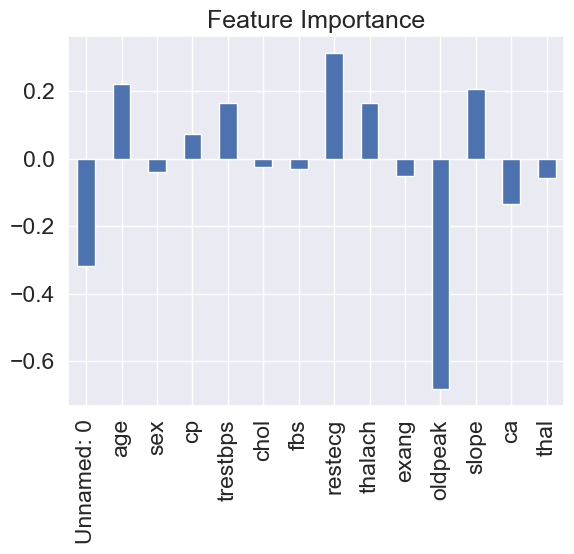

In [237]:
#Visualize feature importance 
feature_df = pd.DataFrame(feature_dict, index=[0])
feature_df.T.plot.bar(title="Feature Importance", legend=False);

In [238]:
pd.crosstab(df["sex"], df["target"])

target,0,1
sex,,
0,24,72
1,114,93


In [239]:
pd.crosstab(df["slope"], df["target"])

target,0,1
slope,,
0,12,9
1,91,49
2,35,107


slope - the slope of the peak exercise ST segment

0: Upsloping: better heart rate with excercise (uncommon)

1: Flatsloping: minimal change (typical healthy heart)

2: Downslopins: signs of unhealthy heart

### 6. Experimentation
If you haven't hit your evaluation metric yet...ask

 *Could you collect more data?

 *Could you try a better model? Like CatBoost or XGBoost?

 *Could you improve the current models? (beyond what we've done so far)

 *If your model is good enough(you have hit your evaluation metric) how would you  export it and share it with others?
